<a href="https://colab.research.google.com/github/dyjdlopez/mapua_ieemg_decision_science/blob/main/IE151P-S/Module%2002/02_01_linear_regression_fit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 02-01: Linear Regression — Fitting the Line, R², and statsmodels

**Companion to Lesson 2.1 (IE151P-S Advanced Computer Applications)** · Part 1 of 2 · about 60–75 minutes

In the lecture you fitted a straight line to the rice-yield trial and measured how well it fits. Here you will do the same thing **by hand with NumPy first**, then meet **statsmodels**, the library professionals use to fit regression models and read their results.

**By the end of this notebook you will be able to:**

1. Compute the slope, intercept, residuals, and SSE by hand and verify them with NumPy.
2. Compute SST, SSR, SSE, $R^2$, and adjusted $R^2$ from their definitions.
3. Explain what statsmodels is, and fit an OLS model with both its array and formula interfaces.
4. Read each field of `results.summary()` and know which ones you can already interpret.
5. Show, with simulations, why $R^2$ always rises when predictors are added and how adjusted $R^2$ behaves.


## Part 0: Setup

We use three libraries now and add a fourth (statsmodels) in Part 3:

| Library | Role in this notebook | Documentation |
|---|---|---|
| [NumPy](https://numpy.org/doc/stable/) | Arrays and the by-hand calculations | `np.sum`, `np.polyfit`, `np.corrcoef` |
| [pandas](https://pandas.pydata.org/docs/) | Tables of data (DataFrames) | `pd.DataFrame` |
| [Matplotlib](https://matplotlib.org/stable/) | Plots | `plt.subplots` |

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# House colors used in the lecture slides
BLUE, RED, ORANGE, GREEN = "#1f618d", "#c0392b", "#e67e22", "#278a4d"

plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

print("NumPy :", np.__version__)
print("pandas:", pd.__version__)

NumPy : 2.4.4
pandas: 3.0.2


### About the data

We reuse the **10-plot rice trial from the lecture**: nitrogen (N) fertilizer rate in kg N/ha against grain yield in kg/ha. These are **illustrative numbers built for teaching, not actual IRRI measurements**, and they are identical to the lecture slides so that your results can be checked against the slides.

## Part 1: Fitting the Line by Hand

**Regression** uses known values (the *predictor*, here N rate) to predict a *numeric* outcome (the *response*, here yield) with a line:

$$\hat{y} = \hat\beta_0 + \hat\beta_1 x$$

The hat on $\hat{y}$ marks a *prediction*. $\hat\beta_0$ is the intercept (predicted yield with no nitrogen) and $\hat\beta_1$ is the slope (extra yield per extra kg of N). First, the data and a plot.

,N_rate_kg_ha,yield_kg_ha
plot,,
1,0.0,3300.0
2,25.0,3600.0
3,50.0,4500.0
4,50.0,4150.0
5,75.0,4800.0
6,100.0,5300.0
7,100.0,5650.0
8,125.0,5800.0
9,150.0,6700.0


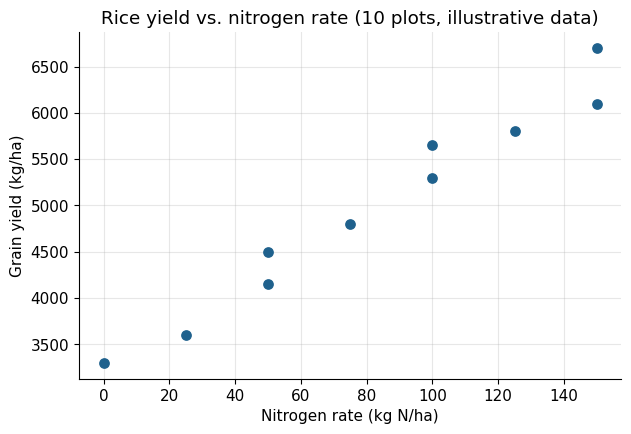

In [ ]:
N_rate = np.array([0, 25, 50, 50, 75, 100, 100, 125, 150, 150], dtype=float)
grain_yield = np.array([3300, 3600, 4500, 4150, 4800, 5300, 5650, 5800, 6700, 6100], dtype=float)

rice = pd.DataFrame(
    {"N_rate_kg_ha": N_rate, "yield_kg_ha": grain_yield},
    index=pd.RangeIndex(1, 11, name="plot"),
)
display(rice)

fig, ax = plt.subplots()
ax.scatter(rice["N_rate_kg_ha"], rice["yield_kg_ha"], color=BLUE, s=45, zorder=3)
ax.set_xlabel("Nitrogen rate (kg N/ha)")
ax.set_ylabel("Grain yield (kg/ha)")
ax.set_title("Rice yield vs. nitrogen rate (10 plots, illustrative data)")
plt.show()

### The slope and intercept formulas

**Plain language:** the slope is *how much $x$ and $y$ move together* divided by *how much $x$ varies on its own*. The intercept then forces the line through the point of averages $(\bar{x}, \bar{y})$.

$$\hat\beta_1 = \frac{S_{xy}}{S_{xx}} = \frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{\sum (x_i-\bar{x})^2}, \qquad \hat\beta_0 = \bar{y} - \hat\beta_1\,\bar{x}$$

In [ ]:
x = rice["N_rate_kg_ha"].to_numpy()
y = rice["yield_kg_ha"].to_numpy()
n = len(x)

x_bar, y_bar = x.mean(), y.mean()
S_xy = np.sum((x - x_bar) * (y - y_bar))
S_xx = np.sum((x - x_bar) ** 2)

b1 = S_xy / S_xx           # slope
b0 = y_bar - b1 * x_bar    # intercept

print(f"x̄ = {x_bar:.1f} kg N/ha,   ȳ = {y_bar:,.1f} kg/ha")
print(f"Sxy = {S_xy:,.1f},   Sxx = {S_xx:,.1f}")
print(f"β̂1 (slope)     = {b1:.4f} kg/ha per kg N")
print(f"β̂0 (intercept) = {b0:,.4f} kg/ha")

assert np.isclose(b1, 21.2388, atol=1e-3) and np.isclose(b0, 3237.795, atol=1e-2)

x̄ = 82.5 kg N/ha,   ȳ = 4,990.0 kg/ha
Sxy = 505,750.0,   Sxx = 23,812.5
β̂1 (slope)     = 21.2388 kg/ha per kg N
β̂0 (intercept) = 3,237.7953 kg/ha


So the fitted line is $\hat{y} \approx 3{,}237.8 + 21.24\,N$: each extra kg N/ha adds about **21 kg/ha** of grain, *on average*. (The lecture's hand-worked slide used only 5 of these 10 plots, which is why it showed 22.7 instead of 21.24; you will reproduce that in Part 3.)

### Residuals and SSE

A **residual** is the vertical miss between what we observed and what the line predicted, $e_i = y_i - \hat{y}_i$. The **Sum of Squared Errors** adds up the squared misses: $\text{SSE} = \sum e_i^2$.

In [ ]:
y_hat = b0 + b1 * x
resid = y - y_hat

table = rice.assign(predicted_kg_ha=y_hat, residual_kg_ha=resid)
display(table.round(1))

SSE = np.sum(resid ** 2)
print("Sum of residuals:", round(resid.sum(), 8), "(always ~0 for least squares with an intercept)")
print(f"SSE = {SSE:,.2f} (kg/ha)²")

assert np.isclose(resid.sum(), 0, atol=1e-6)

,N_rate_kg_ha,yield_kg_ha,predicted_kg_ha,residual_kg_ha
plot,,,,
1,0.0,3300.0,3237.8,62.2
2,25.0,3600.0,3768.8,-168.8
3,50.0,4500.0,4299.7,200.3
4,50.0,4150.0,4299.7,-149.7
5,75.0,4800.0,4830.7,-30.7
6,100.0,5300.0,5361.7,-61.7
7,100.0,5650.0,5361.7,288.3
8,125.0,5800.0,5892.7,-92.7
9,150.0,6700.0,6423.6,276.4


Sum of residuals: 0.0 (always ~0 for least squares with an intercept)
SSE = 372,454.07 (kg/ha)²


### Why is this the *best* line?

Least squares chooses the line with the **smallest possible SSE**. To see it, we try many slopes. For each candidate slope we keep the line through $(\bar{x},\bar{y})$ (the intercept formula above) and compute the SSE. The best slope should sit at the bottom of the curve.

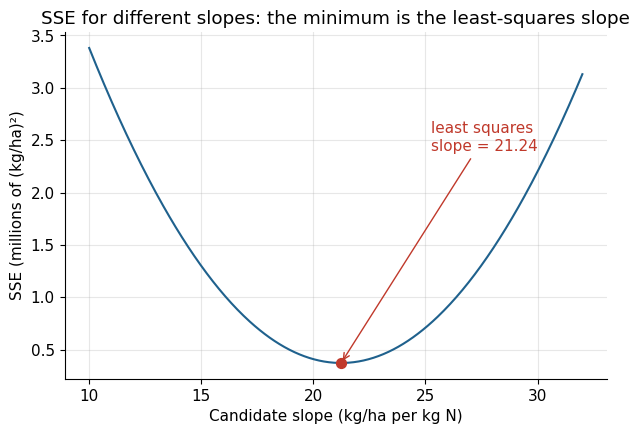

Smallest SSE on the grid is at slope ≈ 21.25; the formula gave 21.24


In [ ]:
slopes = np.linspace(10, 32, 400)
sse_curve = np.array([np.sum((y - ((y_bar - s * x_bar) + s * x)) ** 2) for s in slopes])

fig, ax = plt.subplots()
ax.plot(slopes, sse_curve / 1e6, color=BLUE)
ax.scatter([b1], [SSE / 1e6], color=RED, zorder=3, s=50)
ax.annotate(f"least squares\nslope = {b1:.2f}", xy=(b1, SSE / 1e6), xytext=(b1 + 4, 2.4),
            arrowprops=dict(arrowstyle="->", color=RED), color=RED)
ax.set_xlabel("Candidate slope (kg/ha per kg N)")
ax.set_ylabel("SSE (millions of (kg/ha)²)")
ax.set_title("SSE for different slopes: the minimum is the least-squares slope")
plt.show()

best_on_grid = slopes[np.argmin(sse_curve)]
print(f"Smallest SSE on the grid is at slope ≈ {best_on_grid:.2f}; the formula gave {b1:.2f}")
assert abs(best_on_grid - b1) < 0.1

### Cross-check with NumPy and the correlation link

[`np.polyfit`](https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html) fits the same line in one call. The slope also equals the correlation $r$ rescaled by the spread of $y$ relative to $x$: $\hat\beta_1 = r \cdot s_y / s_x$ (Lesson 1.4's correlation, now turned into a prediction rule).

In [ ]:
b1_np, b0_np = np.polyfit(x, y, deg=1)
r = np.corrcoef(x, y)[0, 1]
b1_from_r = r * y.std(ddof=1) / x.std(ddof=1)

display(pd.DataFrame(
    {"slope": [b1, b1_np, b1_from_r], "intercept": [b0, b0_np, np.nan]},
    index=["by hand (Sxy/Sxx)", "np.polyfit", "r · s_y / s_x"],
).round(4))

assert np.allclose([b1, b0], [b1_np, b0_np]) and np.isclose(b1, b1_from_r)
print(f"r = {r:.4f}")

,slope,intercept
by hand (Sxy/Sxx),21.2388,3237.7953
np.polyfit,21.2388,3237.7953
r · s_y / s_x,21.2388,NaN


r = 0.9831


## Part 2: $R^2$ and Adjusted $R^2$ by Hand

**How good is the line?** Start from the baseline of predicting the average yield $\bar{y}$ for every plot. The total variation around that baseline splits into a part the regression explains and a part it leaves unexplained:

| Quantity | Formula | Plain-language meaning |
|---|---|---|
| **SST** (Total Sum of Squares) | $\sum (y_i-\bar{y})^2$ | Total variation of yield around its average |
| **SSR** (Regression Sum of Squares) | $\sum (\hat{y}_i-\bar{y})^2$ | Variation the regression line explains |
| **SSE** (Error Sum of Squares) | $\sum (y_i-\hat{y}_i)^2$ | Variation left unexplained (the residuals) |

For OLS with an intercept, $\text{SST} = \text{SSR} + \text{SSE}$.

SST =   11,114,000.0


SSR =   10,741,545.9
SSE =      372,454.1
SSR + SSE = 11,114,000.0  (equals SST)


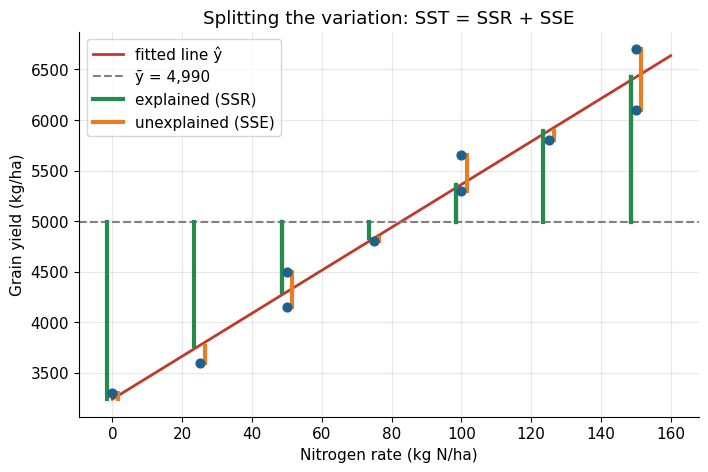

In [ ]:
SST = np.sum((y - y_bar) ** 2)
SSR = np.sum((y_hat - y_bar) ** 2)
SSE = np.sum((y - y_hat) ** 2)

print(f"SST = {SST:>14,.1f}")
print(f"SSR = {SSR:>14,.1f}")
print(f"SSE = {SSE:>14,.1f}")
print(f"SSR + SSE = {SSR + SSE:,.1f}  (equals SST)")
assert np.isclose(SST, SSR + SSE)

# Picture the split: green = explained (ȳ to ŷ), orange = unexplained (ŷ to y)
fig, ax = plt.subplots(figsize=(8, 5))
grid = np.array([0, 160])
ax.plot(grid, b0 + b1 * grid, color=RED, lw=2, label="fitted line ŷ")
ax.axhline(y_bar, color="gray", ls="--", label=f"ȳ = {y_bar:,.0f}")
ax.scatter(x, y, color=BLUE, s=40, zorder=3)
for xi, yi, yhi in zip(x, y, y_hat):
    ax.plot([xi - 1.5, xi - 1.5], [y_bar, yhi], color=GREEN, lw=3)
    ax.plot([xi + 1.5, xi + 1.5], [yhi, yi], color=ORANGE, lw=3)
ax.plot([], [], color=GREEN, lw=3, label="explained (SSR)")
ax.plot([], [], color=ORANGE, lw=3, label="unexplained (SSE)")
ax.set_xlabel("Nitrogen rate (kg N/ha)")
ax.set_ylabel("Grain yield (kg/ha)")
ax.set_title("Splitting the variation: SST = SSR + SSE")
ax.legend()
plt.show()

### $R^2$: the share of variation explained

**Plain language:** $R^2$ is the fraction of the variation in yield that the regression explains, compared with just predicting $\bar{y}$ for every plot.

$$R^2 = \frac{\text{SSR}}{\text{SST}} = 1 - \frac{\text{SSE}}{\text{SST}}$$

In *simple* regression (one predictor), $R^2 = r^2$.

In [ ]:
R2 = SSR / SST
R2_alt = 1 - SSE / SST

print(f"R² = SSR/SST      = {R2:.4f}")
print(f"R² = 1 - SSE/SST  = {R2_alt:.4f}")
print(f"r² (from correlation) = {r**2:.4f}")
print(f"\nAbout {R2*100:.1f}% of the plot-to-plot variation in yield is explained by N rate.")

assert np.isclose(R2, R2_alt) and np.isclose(R2, r ** 2)

R² = SSR/SST      = 0.9665
R² = 1 - SSE/SST  = 0.9665
r² (from correlation) = 0.9665

About 96.6% of the plot-to-plot variation in yield is explained by N rate.


### Adjusted $R^2$: penalizing extra predictors

**Plain language:** every predictor you add uses up one degree of freedom. Adjusted $R^2$ compares the *residual variance estimate* with the *variance of $y$*, each divided by its own degrees of freedom, so an added predictor has to earn its place.

$$R^2_{\text{adj}} = 1 - (1-R^2)\,\frac{n-1}{n-p-1} = 1 - \frac{\text{SSE}/(n-p-1)}{\text{SST}/(n-1)}$$

where $n$ is the number of observations and $p$ is the number of predictors (not counting the intercept).

In [ ]:
p = 1   # one predictor: N rate
R2_adj = 1 - (1 - R2) * (n - 1) / (n - p - 1)
R2_adj_alt = 1 - (SSE / (n - p - 1)) / (SST / (n - 1))

print(f"n = {n}, p = {p}, residual degrees of freedom n-p-1 = {n - p - 1}")
print(f"Adjusted R² (formula 1) = {R2_adj:.4f}")
print(f"Adjusted R² (formula 2) = {R2_adj_alt:.4f}")
print(f"Plain R²                = {R2:.4f}  (adjusted is always ≤ plain)")

assert np.isclose(R2_adj, R2_adj_alt) and R2_adj <= R2

n = 10, p = 1, residual degrees of freedom n-p-1 = 8
Adjusted R² (formula 1) = 0.9623
Adjusted R² (formula 2) = 0.9623
Plain R²                = 0.9665  (adjusted is always ≤ plain)


## Part 3: What Is statsmodels?

Writing out $S_{xy}/S_{xx}$ is great for understanding, but for real work we use a library. **statsmodels** is a Python library for *statistical modeling*: it estimates models such as OLS regression, logistic regression, and time-series models, and (this is the key point) it reports the **inference** that goes with them: standard errors, confidence intervals, $p$-values, and diagnostic tests. It is open source and built on NumPy, SciPy, and pandas (Seabold & Perktold, 2010).

You may also know **scikit-learn**. They overlap, but they answer different questions:

| | **statsmodels** | **scikit-learn** |
|---|---|---|
| Main goal | *Explain* relationships and test hypotheses | *Predict* new data and build ML pipelines |
| Output | Rich summary: coefficients, standard errors, $p$-values, tests | Predictions and scores; no built-in $p$-values |
| Intercept | **Not** added automatically | Added automatically (`fit_intercept=True`) |
| Argument order | `OLS(y, X)` | `.fit(X, y)` |
| Interfaces | NumPy/pandas arrays **and** R-style formulas | Arrays only |

Useful links: [statsmodels home](https://www.statsmodels.org/stable/index.html) · [`OLS`](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html) · [`RegressionResults`](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.RegressionResults.html) · [formula interface](https://www.statsmodels.org/stable/example_formulas.html) · [scikit-learn `LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html). statsmodels comes pre-installed in Google Colab.

In [ ]:
import statsmodels
import statsmodels.api as sm             # array interface (and most tools)
import statsmodels.formula.api as smf    # R-style formula interface

print("statsmodels:", statsmodels.__version__)

statsmodels: 0.15.0


### Fitting OLS: the five-step recipe

**OLS** (Ordinary Least Squares) is the least-squares fit you just did by hand. In statsmodels:

1. Define the response **y**.
2. Build the design matrix **X**: your predictor columns **plus a column of 1s** for the intercept ([`sm.add_constant`](https://www.statsmodels.org/stable/generated/statsmodels.tools.tools.add_constant.html)).
3. Create the model: `model = sm.OLS(y, X)`. This only *describes* the problem.
4. Fit it: `results = model.fit()`. This does the math.
5. Inspect `results` (coefficients, `.summary()`, and more).

In [ ]:
X = sm.add_constant(rice[["N_rate_kg_ha"]])    # adds a column of 1s named "const"
display(X.head(3))

model = sm.OLS(rice["yield_kg_ha"], X)         # y FIRST, then X
results = model.fit()

print(type(model).__name__, "->", type(results).__name__)
print()
print(results.params)

# With plain NumPy arrays the columns have no names, so the summary calls them const / x1
res_np = sm.OLS(y, sm.add_constant(x)).fit()
print()
print(res_np.summary().tables[1])

,const,N_rate_kg_ha
plot,,
1,1.0,0.0
2,1.0,25.0
3,1.0,50.0


OLS -> RegressionResultsWrapper

const           3237.795276
N_rate_kg_ha      21.238845
dtype: float64

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3237.7953    134.026     24.158      0.000    2928.732    3546.859
x1            21.2388      1.398     15.189      0.000      18.014      24.463


**Three habits to build (these are the most common statsmodels mistakes):**

- **Add the constant yourself.** statsmodels will *not* add an intercept unless you do (or use the formula interface). Forgetting it is a silent error; you will see its effect at the end of this part.
- **Order is `OLS(y, X)`**, the reverse of scikit-learn's `fit(X, y)`.
- **Use pandas columns** (as above) to get readable coefficient names. NumPy arrays give anonymous `x1`.

### The formula interface

The formula interface lets you write the model the way you would say it: `"yield ~ N"` reads *"yield is modeled by N"*. It adds the intercept for you.

In [ ]:
results_f = smf.ols("yield_kg_ha ~ N_rate_kg_ha", data=rice).fit()
print(results_f.params)

# Same fit as the array interface
assert np.allclose(results.params.values, results_f.params.values)
print("\nArray interface and formula interface agree.")

Intercept       3237.795276
N_rate_kg_ha      21.238845
dtype: float64

Array interface and formula interface agree.


### What is inside `results`?

`.fit()` returns a **results object** that stores everything about the fitted model. Think of `model` as the recipe and `results` as the finished dish plus its nutrition label. The attributes you will use most:

| Attribute | Meaning |
|---|---|
| `.params` | Estimated coefficients $\hat\beta$ |
| `.bse`, `.tvalues`, `.pvalues`, `.conf_int()` | Inference on each coefficient (decoded in Notebook 02-02) |
| `.rsquared`, `.rsquared_adj` | $R^2$ and adjusted $R^2$ |
| `.fittedvalues`, `.resid` | $\hat{y}$ and the residuals |
| `.predict(new_X)` | Predictions for new data |

In [ ]:
coef_table = pd.DataFrame({
    "coef": results.params,
    "std err": results.bse,
    "t": results.tvalues,
    "P>|t|": results.pvalues,
})
coef_table[["[0.025", "0.975]"]] = results.conf_int().to_numpy()
display(coef_table.round(4))

print(f"R²       = {results.rsquared:.4f}")
print(f"Adj. R²  = {results.rsquared_adj:.4f}")

# Predictions: formula results accept a DataFrame of the raw predictor
new = pd.DataFrame({"N_rate_kg_ha": [40, 80, 120]})
pred = results_f.predict(new)
pred_arrays = results.predict(sm.add_constant(new, has_constant="add"))
by_hand = b0 + b1 * new["N_rate_kg_ha"]

print("\nPredicted yield (kg/ha):")
display(pd.DataFrame({"N_rate_kg_ha": new["N_rate_kg_ha"], "predicted_yield": pred.round(1)}))
assert np.allclose(pred, by_hand) and np.allclose(pred_arrays, by_hand)

,coef,std err,t,P>|t|,[0.025,0.975]
const,3237.7953,134.0255,24.1580,0.0,2928.7318,3546.8587
N_rate_kg_ha,21.2388,1.3983,15.1894,0.0,18.0144,24.4632


R²       = 0.9665
Adj. R²  = 0.9623

Predicted yield (kg/ha):


,N_rate_kg_ha,predicted_yield
0,40,4087.3
1,80,4936.9
2,120,5786.5


### Reading `results.summary()`

The summary packs the whole analysis into one printout with **four blocks**. Print it first, then we decode it block by block.

In [ ]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:            yield_kg_ha   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.962
Method:                 Least Squares   F-statistic:                     230.7
Date:                Sat, 03 Oct 2026   Prob (F-statistic):           3.50e-07
Time:                        04:08:32   Log-Likelihood:                -66.816
No. Observations:                  10   AIC:                             137.6
Df Residuals:                       8   BIC:                             138.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         3237.7953    134.026     24.158   

#### Block 1: top left (the model's identity)

| Field | Meaning |
|---|---|
| **Dep. Variable** | The response $y$ being modeled |
| **Model**, **Method** | OLS, fitted by Least Squares |
| **Date**, **Time** | When you ran it (ignore) |
| **No. Observations** | $n$, the number of plots |
| **Df Residuals** | $n-p-1$: degrees of freedom left over to estimate the error (used by the $t$ and $F$ tests) |
| **Df Model** | $p$, the number of predictors (the constant is not counted) |
| **Covariance Type** | `nonrobust` means the standard errors assume independent, constant-variance errors; robust options come in Notebook 02-02 |

#### Block 2: top right (overall fit)

| Field | Where you meet it |
|---|---|
| **R-squared**, **Adj. R-squared** | **This notebook** (Parts 2 and 4) |
| **F-statistic**, **Prob (F-statistic)** | Notebook 02-02: the overall significance test |
| **Log-Likelihood**, **AIC**, **BIC** | Notebook 02-02: model comparison criteria |

#### Block 3: the coefficient table

| Column | Meaning | Where you meet it |
|---|---|---|
| **coef** | The estimated $\hat\beta$ (const = $\hat\beta_0$, N = $\hat\beta_1$) | **This notebook** (Part 1) |
| **std err**, **t**, **P>\|t\|**, **[0.025 0.975]** | Uncertainty of each coefficient, its $t$-test, and 95% confidence interval | Notebook 02-02 |

The next cell checks every field marked "this notebook" against your by-hand numbers.

In [ ]:
checks = {
    "No. Observations (n)":            (results.nobs,        n),
    "Df Residuals = n - p - 1":        (results.df_resid,    n - 1 - 1),
    "Df Model = p":                    (results.df_model,    1),
    "R-squared":                       (results.rsquared,    R2),
    "Adj. R-squared":                  (results.rsquared_adj, R2_adj),
    "coef: const (β̂0)":                (results.params["const"],        b0),
    "coef: N_rate_kg_ha (β̂1)":         (results.params["N_rate_kg_ha"], b1),
}
report = pd.DataFrame(
    [(name, sm_val, hand, np.isclose(sm_val, hand)) for name, (sm_val, hand) in checks.items()],
    columns=["summary field", "statsmodels", "by hand", "match"],
)
display(report.round(4))
assert report["match"].all()

,summary field,statsmodels,by hand,match
0,No. Observations (n),10.0000,10.0000,True
1,Df Residuals = n - p - 1,8.0000,8.0000,True
2,Df Model = p,1.0000,1.0000,True
3,R-squared,0.9665,0.9665,True
4,Adj. R-squared,0.9623,0.9623,True
5,coef: const (β̂0),3237.7953,3237.7953,True
6,coef: N_rate_kg_ha (β̂1),21.2388,21.2388,True


#### Block 4: bottom (residual diagnostics)

| Field | What it checks | Where you meet it |
|---|---|---|
| **Omnibus**, **Prob(Omnibus)**, **Skew**, **Kurtosis**, **Jarque-Bera (JB)**, **Prob(JB)** | Are the residuals normally distributed? | Notebook 02-02 |
| **Durbin-Watson** | Are consecutive residuals correlated (autocorrelation)? | Notebook 02-02 |
| **Cond. No.** | Condition number: a warning light for multicollinearity and badly scaled predictors | Notebook 02-02 |

**A caution about small samples.** These bottom-block diagnostics rest on large-sample theory, and our trial has only $n = 10$ plots. Treat their values here as a demonstration of *where to look*, not as verdicts. With so few observations, almost no test can detect a violation even when one exists.

### Pitfall: forgetting the constant

What happens if we fit `OLS(y, X)` with a predictor column but no column of 1s? Let us find out, and compare against the correct fit.

                                 OLS Regression Results                                
Dep. Variable:            yield_kg_ha   R-squared (uncentered):                   0.894
Model:                            OLS   Adj. R-squared (uncentered):              0.882
Method:                 Least Squares   F-statistic:                              75.99
Date:                Sat, 03 Oct 2026   Prob (F-statistic):                    1.11e-05
Time:                        04:08:32   Log-Likelihood:                         -88.333
No. Observations:                  10   AIC:                                      178.7
Df Residuals:                       9   BIC:                                      179.0
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
Slope with intercept   : 21.24 kg/ha per kg N
Slope without intercept: 50.31 kg/ha per kg N


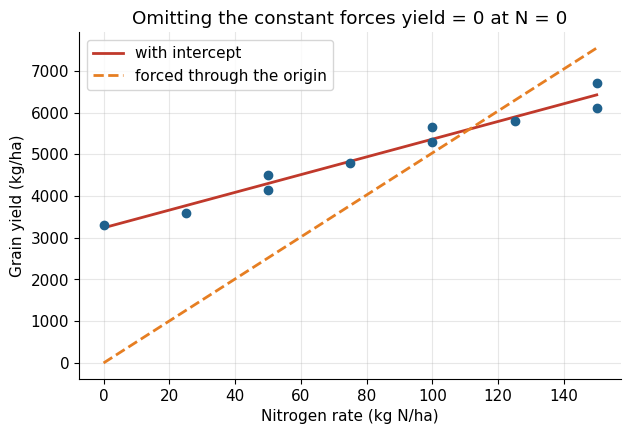

In [ ]:
no_const = sm.OLS(rice["yield_kg_ha"], rice[["N_rate_kg_ha"]]).fit()   # no constant!

print(no_const.summary().tables[0])
print("Slope with intercept   :", round(results.params["N_rate_kg_ha"], 2), "kg/ha per kg N")
print("Slope without intercept:", round(no_const.params["N_rate_kg_ha"], 2), "kg/ha per kg N")

fig, ax = plt.subplots()
grid = np.array([0, 150])
ax.scatter(x, y, color=BLUE, zorder=3)
ax.plot(grid, b0 + b1 * grid, color=RED, lw=2, label="with intercept")
ax.plot(grid, no_const.params["N_rate_kg_ha"] * grid, color=ORANGE, lw=2, ls="--", label="forced through the origin")
ax.set_xlabel("Nitrogen rate (kg N/ha)")
ax.set_ylabel("Grain yield (kg/ha)")
ax.set_title("Omitting the constant forces yield = 0 at N = 0")
ax.legend()
plt.show()

**What we see:** without a constant, the line is forced through the origin, which says a plot with *no* nitrogen yields *zero* grain. The data clearly disagree (yield is about 3,200 kg/ha at N = 0), so the slope is badly distorted (about 50 instead of 21 kg/ha per kg N). Notice also that the header now says **R-squared (uncentered)**: the baseline changed from $\bar{y}$ to 0, so that $R^2$ is **not comparable** with the 0.966 from the correct model. Always check which version of $R^2$ you are reading.

### Your turn

The lecture's hand-worked slide used 5 of the 10 plots (plots 1, 3, 5, 7, and 9). Using the **formula interface**, fit the same line to just those 5 plots. You should get a slope of 22.7 and an intercept of 3,287.5. Then read off $R^2$ and adjusted $R^2$.

In [ ]:
# YOUR TURN
# 1. Select plots 1, 3, 5, 7, 9 from `rice` (hint: rice.loc[[...]])
# 2. Fit smf.ols("yield_kg_ha ~ N_rate_kg_ha", data=...).fit()
# 3. Print the coefficients, results.rsquared, and results.rsquared_adj

In [ ]:
# SOLUTION: try it yourself first
subset = rice.loc[[1, 3, 5, 7, 9]]
res5 = smf.ols("yield_kg_ha ~ N_rate_kg_ha", data=subset).fit()

print(res5.params.round(2))
print(f"R² = {res5.rsquared:.4f},  Adj. R² = {res5.rsquared_adj:.4f}")

assert np.allclose(res5.params.values, [3287.5, 22.7])

Intercept       3287.5
N_rate_kg_ha      22.7
dtype: float64
R² = 0.9922,  Adj. R² = 0.9896


The 5-plot fit reproduces the slide (3,287.5 + 22.7 N). Notice its $R^2$ (about 0.992) is *higher* than the 10-plot fit's 0.966, even though it uses **less data**. That is not a better model: those five plots simply happen to sit closer to a line. $R^2$ measures how well *this sample* is explained, not how trustworthy the estimate is.

## Part 4: $R^2$ vs. Adjusted $R^2$ with statsmodels

**A rule with no exceptions:** adding a predictor to an OLS model can never *lower* $R^2$. Why? OLS is free to give the new predictor a coefficient of zero, which would leave SSE unchanged, so the best fit can only do as well or better. That makes $R^2$ easy to inflate. Adjusted $R^2$ charges a degrees-of-freedom penalty to push back.

We test this by adding a column of **pure random numbers** (noise that has nothing to do with yield) to the rice model.

In [ ]:
rng = np.random.default_rng(1)
rice_noise = rice.assign(noise=rng.normal(size=n))

m1 = smf.ols("yield_kg_ha ~ N_rate_kg_ha", data=rice_noise).fit()
m2 = smf.ols("yield_kg_ha ~ N_rate_kg_ha + noise", data=rice_noise).fit()

comparison = pd.DataFrame({
    "predictors": ["N", "N + random noise"],
    "R²": [m1.rsquared, m2.rsquared],
    "Adj. R²": [m1.rsquared_adj, m2.rsquared_adj],
})
display(comparison.round(4))
print(f"R² change     : {m2.rsquared - m1.rsquared:+.4f}")
print(f"Adj. R² change: {m2.rsquared_adj - m1.rsquared_adj:+.4f}")

assert m2.rsquared > m1.rsquared and m2.rsquared_adj < m1.rsquared_adj

,predictors,R²,Adj. R²
0,N,0.9665,0.9623
1,N + random noise,0.9668,0.9573


R² change     : +0.0003
Adj. R² change: -0.0050


With this particular noise column, $R^2$ rose (barely) while adjusted $R^2$ fell, matching the lecture's demo. But one random draw is an anecdote. Is that what usually happens? Let us repeat the experiment **500 times** for 0 to 6 junk predictors, with a different random column each time.

,mean R²,R² ever fell?,adj R² 10th pct,adj R² median,adj R² 90th pct,% draws adj R² fell
junk predictors,,,,,,
0,0.9665,False,0.9623,0.9623,0.9623,0.0
1,0.9705,False,0.9570,0.9601,0.9703,64.2
2,0.9748,False,0.9513,0.9598,0.9763,57.2
3,0.9786,False,0.9456,0.9601,0.9790,54.6
4,0.9839,False,0.9388,0.9651,0.9868,45.4
5,0.9875,False,0.9322,0.9650,0.9903,46.2
6,0.9920,False,0.9246,0.9682,0.9952,41.2


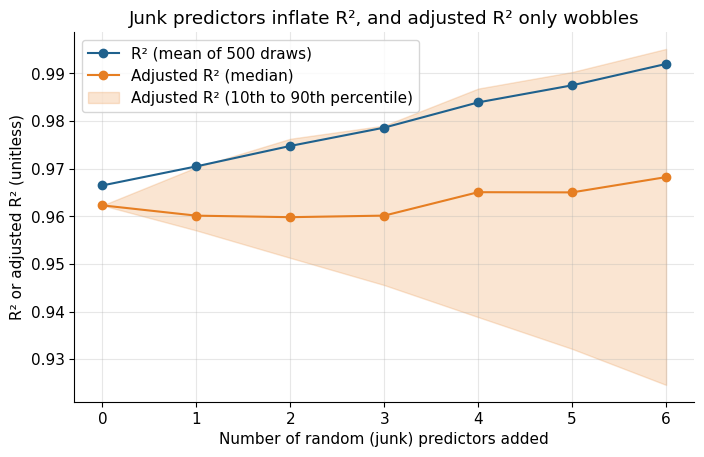

In [ ]:
def junk_sweep(k, n_sims=500):
    # Fit y ~ N + k random columns, n_sims times. Return arrays of R² and adjusted R².
    R, A = [], []
    for seed in range(n_sims):
        Z = np.random.default_rng(seed).normal(size=(n, k))
        fit = sm.OLS(y, sm.add_constant(np.column_stack([x, Z]))).fit()
        R.append(fit.rsquared)
        A.append(fit.rsquared_adj)
    return np.array(R), np.array(A)

base_R2, base_adj = results.rsquared, results.rsquared_adj
rows = []
for k in range(0, 7):
    R, A = junk_sweep(k)
    rows.append({
        "junk predictors": k,
        "mean R²": R.mean(),
        "R² ever fell?": bool((R < base_R2 - 1e-12).any()),
        "adj R² 10th pct": np.percentile(A, 10),
        "adj R² median": np.percentile(A, 50),
        "adj R² 90th pct": np.percentile(A, 90),
        "% draws adj R² fell": 100 * (A < base_adj).mean(),
    })
sweep = pd.DataFrame(rows).set_index("junk predictors")
display(sweep.round(4))

fig, ax = plt.subplots(figsize=(8, 4.8))
ks = sweep.index
ax.plot(ks, sweep["mean R²"], color=BLUE, marker="o", label="R² (mean of 500 draws)")
ax.plot(ks, sweep["adj R² median"], color=ORANGE, marker="o", label="Adjusted R² (median)")
ax.fill_between(ks, sweep["adj R² 10th pct"], sweep["adj R² 90th pct"], color=ORANGE, alpha=0.2,
                label="Adjusted R² (10th to 90th percentile)")
ax.set_xlabel("Number of random (junk) predictors added")
ax.set_ylabel("R² or adjusted R² (unitless)")
ax.set_title("Junk predictors inflate R², and adjusted R² only wobbles")
ax.legend(loc="upper left")
plt.show()

# Guard the claims written below
assert not sweep["R² ever fell?"].any()
assert abs(sweep.loc[1, "% draws adj R² fell"] - 64.2) < 1.0
assert abs(sweep.loc[6, "% draws adj R² fell"] - 41.2) < 1.0

**What the 500 simulations show (read the numbers above, not a slogan):**

- **$R^2$ never fell, in any draw.** Its mean climbs from 0.966 to 0.992 as we add pure noise. By $R^2$ alone, six junk predictors make the model look *much* better.
- **Adjusted $R^2$ does not reward the junk, but it is not a perfect lie detector.** Its median stays around 0.96 to 0.97. With one junk predictor, adjusted $R^2$ fell below the baseline in about 64% of draws, which means that in about **36% of draws a useless predictor made adjusted $R^2$ go up by luck**. With six junk predictors it fell in only about 41%.
- **The spread widens.** The 10th-to-90th percentile band grows as predictors are added: with only $n = 10$ plots, each extra predictor leaves fewer degrees of freedom and makes the estimate noisier.

**Takeaway:** use adjusted $R^2$ as a *guard* against obvious inflation, not as proof that a predictor is useful. Proper evidence comes from tests and information criteria (the $t$-test, $F$-test, and AIC/BIC in Notebook 02-02).

### Your turn

$N^2$ is *not* random noise, since it is built from N itself. Fit `yield ~ N + N²` (hint: in a formula, write `I(N_rate_kg_ha**2)`). Does adjusted $R^2$ improve over the straight-line model?

In [ ]:
# YOUR TURN
# 1. Fit smf.ols("yield_kg_ha ~ N_rate_kg_ha + I(N_rate_kg_ha**2)", data=rice).fit()
# 2. Compare its R² and adjusted R² with the straight-line model (R² = 0.9665, adj = 0.9623)

In [ ]:
# SOLUTION: try it yourself first
quad = smf.ols("yield_kg_ha ~ N_rate_kg_ha + I(N_rate_kg_ha**2)", data=rice).fit()
print(f"Straight line : R² = {results.rsquared:.4f},  Adj. R² = {results.rsquared_adj:.4f}")
print(f"With N² term  : R² = {quad.rsquared:.4f},  Adj. R² = {quad.rsquared_adj:.4f}")
assert quad.rsquared >= results.rsquared and quad.rsquared_adj < results.rsquared_adj

Straight line : R² = 0.9665,  Adj. R² = 0.9623
With N² term  : R² = 0.9668,  Adj. R² = 0.9573


**A null result, and a teaching moment:** the N² term nudges $R^2$ up (it always does) but adjusted $R^2$ goes *down*, to 0.9573, the same as the noise column. For these 10 plots the relationship is close enough to a straight line that curvature adds nothing the data can support. (Notice the model is still a *linear regression*: it is linear in the **parameters** $\beta$, even with an $N^2$ column. Notebook 02-02 returns to this when we test linearity.)

## Part 5: Independent Practice (Palmer Penguins)

Now apply everything to **real data** you already know from Notebook 01-01: body mass of Antarctic penguins (Gorman et al., 2014; Horst, Hill & Gorman, 2020). Can flipper length predict body mass?

**Your tasks:**

1. Regress `body_mass_g` on `flipper_length_mm` **by hand** (slope, intercept, $R^2$) with NumPy.
2. Fit the same model with statsmodels (formula interface) and confirm the numbers match.
3. Add `bill_length_mm`, then separately `bill_depth_mm`, then both. For each model record $R^2$ and adjusted $R^2$. Which additions help? Which do not?
4. Write two or three sentences interpreting the slope in grams per millimeter and judging whether the extra predictors earned their place.

The next cell loads the data (via the GitHub raw CSV, as in Notebook 01-01) and keeps only penguins with all four measurements.

In [ ]:
URL = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv"
penguins = pd.read_csv(URL)

cols = ["body_mass_g", "flipper_length_mm", "bill_length_mm", "bill_depth_mm"]
d = penguins.dropna(subset=cols).copy()

print(f"Rows in file: {len(penguins)}, rows with all four measurements: {len(d)}")
display(d[cols].describe().round(1))

# YOUR WORK BELOW
# Task 1: by-hand slope, intercept, R² for body_mass_g ~ flipper_length_mm
# Task 2: the same model with smf.ols(...); assert the numbers match
# Task 3: add bill_length_mm, then bill_depth_mm, then both; tabulate R² and adjusted R²

Rows in file: 344, rows with all four measurements: 342


,body_mass_g,flipper_length_mm,bill_length_mm,bill_depth_mm
count,342.0,342.0,342.0,342.0
mean,4201.8,200.9,43.9,17.2
std,802.0,14.1,5.5,2.0
min,2700.0,172.0,32.1,13.1
25%,3550.0,190.0,39.2,15.6
50%,4050.0,197.0,44.4,17.3
75%,4750.0,213.0,48.5,18.7
max,6300.0,231.0,59.6,21.5


### Checkpoints (check your work against these)

| Model | $R^2$ | Adjusted $R^2$ |
|---|---|---|
| `body_mass_g ~ flipper_length_mm` ($n = 342$) | 0.7590 | 0.7583 |
| `+ bill_length_mm` | 0.7600 | 0.7585 |
| `+ bill_depth_mm` | 0.7610 | 0.7596 |
| `+ both` | 0.7615 | 0.7594 |

For the simple model, the slope is about **49.7 g per mm** of flipper length and the intercept is about **−5,781 g**. (The intercept is a mathematical anchor, not a real prediction: no penguin has a flipper length of 0 mm.)

**What to notice:** flipper length alone already explains about 76% of the variation in body mass, and the extra bill measurements add almost nothing: $R^2$ rises by less than 0.003 in total, and adjusted $R^2$ barely moves. That is an honest null result: more predictors did not make a materially better model.

## Summary and What Comes Next

| Concept | Formula | Python |
|---|---|---|
| Slope, intercept | $\hat\beta_1 = S_{xy}/S_{xx}$, $\hat\beta_0 = \bar{y}-\hat\beta_1\bar{x}$ | `np.polyfit`, `results.params` |
| Residuals, SSE | $e_i = y_i-\hat{y}_i$, $\sum e_i^2$ | `results.resid` |
| $R^2$ | $\text{SSR}/\text{SST} = 1-\text{SSE}/\text{SST}$ | `results.rsquared` |
| Adjusted $R^2$ | $1-(1-R^2)\frac{n-1}{n-p-1}$ | `results.rsquared_adj` |
| Fit an OLS model | y, X with a constant | `sm.OLS(y, sm.add_constant(X)).fit()` or `smf.ols("y ~ x", data=df).fit()` |

**Remember:** statsmodels needs you to add the constant (or use a formula), takes `OLS(y, X)` in that order, and its `summary()` has four blocks, of which you can now read the model identity, $R^2$ and adjusted $R^2$, and the coefficients.

**Next: Notebook 02-02** decodes the rest of the summary (standard errors, $t$, $F$, AIC/BIC) and tests the assumptions behind OLS: linearity, multicollinearity, autocorrelation, heteroskedasticity, and normality.

---
**References.** Seabold, S., & Perktold, J. (2010). Statsmodels: Econometric and statistical modeling with Python. *Proceedings of the 9th Python in Science Conference*. · Gorman, K. B., Williams, T. D., & Fraser, W. R. (2014). Ecological sexual dimorphism and environmental variability within a community of Antarctic penguins (genus *Pygoscelis*). *PLoS ONE, 9*(3), e90081. · Horst, A. M., Hill, A. P., & Gorman, K. B. (2020). palmerpenguins: Palmer Archipelago (Antarctica) penguin data. R package version 0.1.0. https://doi.org/10.5281/zenodo.3960218

© 2026 Engr. Dylan Josh D. Lopez. All rights reserved.